In [2]:
import sys
import os

# Go up one directory level to the project root and add it to the path
project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)

# Verify it worked (should print the path to your ML-in-ChemEng-PINN folder)
print(f"Project root added to path: {project_root}")

Project root added to path: c:\Technion\Semester 6\ML-in-ChemEng-PINN


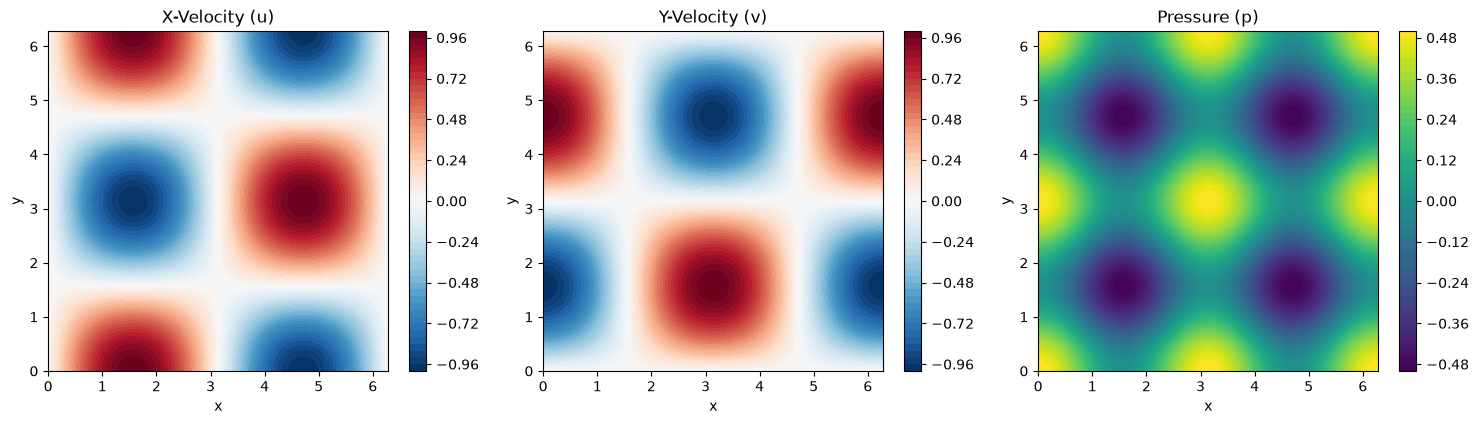

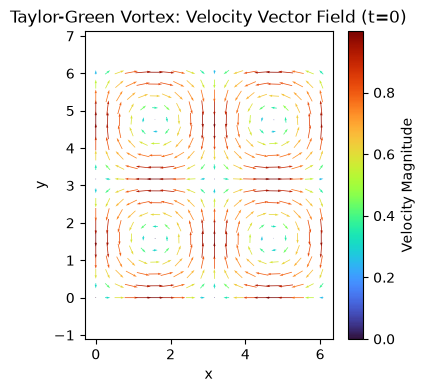

In [ ]:
import torch
import math
import matplotlib.pyplot as plt
from src.physics.taylor_green import compute_nu, compute_T, generate_tgv

# 1. Setup Parameters
U0 = 1.0
Re = 100.0
k = 1
nu = compute_nu(U0, Re, k)
T = compute_T(U0, Re, k) # Final simulation time

# 2. Create a 2D Grid (100x100 resolution from 0 to 2*pi)
grid_points = 100
x_linspace = torch.linspace(0, 2 * math.pi, grid_points)
y_linspace = torch.linspace(0, 2 * math.pi, grid_points)

# meshgrid creates the 2D coordinate arrays
Y, X = torch.meshgrid(y_linspace, x_linspace, indexing='ij') 
t = torch.tensor(0.0) # Look at the initial state (t=0)

# 3. Generate the analytical fields using your function
u, v, p = generate_tgv(X, Y, t, U0, k, phi_x=0.0, phi_y=0.0, nu=nu)

# 4. Plot the results
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot X-Velocity (u)
im0 = axes[0].contourf(X.numpy(), Y.numpy(), u.numpy(), levels=50, cmap='RdBu_r')
axes[0].set_title('X-Velocity (u)')
fig.colorbar(im0, ax=axes[0])

# Plot Y-Velocity (v)
im1 = axes[1].contourf(X.numpy(), Y.numpy(), v.numpy(), levels=50, cmap='RdBu_r')
axes[1].set_title('Y-Velocity (v)')
fig.colorbar(im1, ax=axes[1])

# Plot Pressure (p)
im2 = axes[2].contourf(X.numpy(), Y.numpy(), p.numpy(), levels=50, cmap='viridis')
axes[2].set_title('Pressure (p)')
fig.colorbar(im2, ax=axes[2])

for ax in axes:
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()

# 1. Define a skipping factor (plot an arrow every 4th point)
skip = 5

# 2. Subsample the tensors for visual clarity
X_sub = X[::skip, ::skip].numpy()
Y_sub = Y[::skip, ::skip].numpy()
u_sub = u[::skip, ::skip].numpy()
v_sub = v[::skip, ::skip].numpy()

# 3. Calculate the magnitude (speed) for coloring the arrows
speed = torch.sqrt(u**2 + v**2)[::skip, ::skip].numpy()

# 4. Create the plot
plt.figure(figsize=(4, 4))

# plt.quiver takes the X, Y coordinates, the u, v direction vectors, 
# and we pass 'speed' to color-code the arrows based on how fast the fluid is moving
quiver = plt.quiver(X_sub, Y_sub, u_sub, v_sub, speed, 
                    cmap='turbo', scale=15, pivot='mid')

plt.title('Taylor-Green Vortex: Velocity Vector Field (t=0)')
plt.xlabel('x')
plt.ylabel('y')
plt.colorbar(quiver, label='Velocity Magnitude')
plt.axis('equal')
plt.show()